The aim of this notebook is to compare NBr54 against 52. In 54 qrun is much smaller for no apparent reason.

For this reason, I'll compare the MSW input files for both runs.

The outcom from the comparrison is recorded in ./MSW_In_NBr54_Vs_NBr52.xlsx

# 0. Basics

## 0.0 Imports

In [1]:
import pandas as pd
from WS_Mdl.core import *
import xarray as xra
import matplotlib.pyplot as plt

## 0.1 Options

In [4]:
M = Mdl_N('NBr60')
MB = Mdl_N('NBr52')

In [5]:
Aa = M.Mdl_area - M.N_R*2*M.cellsize - (M.N_C-2)*2*M.cellsize
Aa

103158900.0

# 1. Load MSW Ins as DFs

In [6]:
# DS = M.MSW_In.DS

In [7]:
# d_DF = {M.MdlN: {}, MB.MdlN: {}}

In [ ]:
# for m in M, MB:    
#     for i, F in enumerate(list(m.Pa.MSW.glob('*.inp'))):
#         print(i+1, end=' ')
#         DF = r_MSW_In.MSW_In_to_DF(F)
#         d_DF[m.MdlN][F.stem.lower()] = DF.rename(columns={'SVAT': 'SVAT'}) if isinstance(DF, pd.DataFrame) else DF # To avoid crashing when MSW_In_to_DF returns None.

# 2. Explore MSW In files

Procedure works as follows:
1. Check if DFs for Fis are identical (.equals) (Status=3)
2. If not, check if they're almost identical (Status=2) or mostly similar (Status=1), or problematic (Status=0)

## 2.0 idf_svat
Starting with this one cause it'll tell help us find the extra SVATs in NBr54, which will be useful for the other 

### Load & Clean

In [9]:
Fi = 'idf_svat'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

 1 - area_svat.inp 🟢
 2 - fact_svat.inp 🟢
 3 - idf_svat.inp 🟢
 4 - infi_svat.inp 🟢
 5 - init_svat.inp 🟢
 6 - luse_svat.inp 🟢
 7 - mete_grid.inp 🟢
 8 - mod2svat.inp 🟢
 9 - para_sim.inp 🟢
10 - scap_svat.inp 🟡 - Missing 8 columns
11 - sel_key_svat_per.inp 🟢
12 - svat2etrefgrid.inp 🟢
13 - svat2precgrid.inp 🟢
14 - svat2swnr_roff.inp 🟢
15 - time_sim.inp 🟡 - Missing 2 columns
16 - tiop_sim.inp 🟢
 1 - area_svat.inp 🟢
 2 - fact_svat.inp 🟢
 3 - idf_svat.inp 🟢
 4 - infi_svat.inp 🟢
 5 - init_svat.inp 🟢
 6 - luse_svat.inp 🟢
 7 - mete_grid.inp 🟢
 8 - mod2svat.inp 🟢
 9 - para_sim.inp 🟢
10 - scap_svat.inp 🟡 - Missing 8 columns
11 - sel_key_svat_per.inp 🟢
12 - sel_svat_bda.inp 🔴 'sel_svat_bda.inp'
13 - svat2etrefgrid.inp 🟢
14 - svat2precgrid.inp 🟡 - Missing 2 columns
15 - svat2swnr_roff.inp 🟢
16 - time_sim.inp 🟡 - Missing 2 columns
17 - tiop_sim.inp 🟢
18 - uscl_svat.inp 🟡 - Missing 2 columns


False

In [10]:
DF.rename(columns={'row number of gridcell (MODFLOW style)': 'R', 'column number of gridcell (MODFLOW style)': 'C'}, inplace=True)
DF_B.rename(columns={'row number of gridcell (MODFLOW style)': 'R', 'column number of gridcell (MODFLOW style)': 'C'}, inplace=True)

### Inspect

In [11]:
DF.describe()

,SVAT,R,C,X,Y
count,184024.000000,184024.000000,184024.000000,184024.000000,184024.00000
mean,92012.500000,168.473878,245.539783,119225.994571,392000.65304
std,53123.297306,100.363154,139.939980,3498.499490,2509.07884
min,1.000000,2.000000,2.000000,113137.500000,387637.50000
25%,46006.750000,78.000000,124.000000,116187.500000,389787.50000
50%,92012.500000,169.000000,247.000000,119262.500000,391987.50000
75%,138018.250000,257.000000,369.000000,122312.500000,394262.50000
max,184024.000000,343.000000,479.000000,125062.500000,396162.50000


In [12]:
DF_B.describe()

,SVAT,R,C,X,Y
count,183388.00000,183388.000000,183388.000000,183388.000000,183388.000000
mean,91694.50000,168.676287,245.710188,119230.298466,391995.593087
std,52939.69992,100.378936,139.833887,3495.872738,2509.473601
min,1.00000,2.000000,2.000000,113137.500000,387637.500000
25%,45847.75000,78.000000,124.000000,116187.500000,389787.500000
50%,91694.50000,169.000000,247.000000,119262.500000,391987.500000
75%,137541.25000,257.000000,369.000000,122312.500000,394262.500000
max,183388.00000,343.000000,479.000000,125062.500000,396162.500000


Seems like imod_python creates SVATs in a different way than imod5, as even though we've now removed the outer rows and columns, there are still more SVATs in NBr60 than in NBr52. Let's explore this further.

### investigate SVAT Diffs

There are 165120 (N_R*N_C) cells in the model. There are more SVATs than that though (even though the first and last row and column are inactive in iMOD5). That is because cells with urban_area>0 get 2 SVATs (I checked in QGIS).

In [13]:
DF['R_C'] = DF['R'].astype(str) + '_' + DF['C'].astype(str)
DF_B['R_C'] = DF_B['R'].astype(str) + '_' + DF_B['C'].astype(str)

In [14]:
print(f"{len(DF)-len(DF_B)} SVAT grid cells in NBr54 that are not in NBr52 - {(len(DF)-len(DF_B))/len(DF)*100:.2f}%")

636 SVAT grid cells in NBr54 that are not in NBr52 - 0.35%


I explore this later

In [15]:
DF.loc[DF['R_C'].isin(DF_B['R_C']) == False]

,SVAT,R,C,X,Y,R_C
105399,105400,222,241,119112.5,390662.5,222_241


This is the only R_C that's completely missing from B. It is fully wetted (625m2 wetted area), so it might make sense imod5 removed it. 

### Plot DSs to explore SVAT creation in NBr60 vs NBr52

In [16]:
DS = M.MSW_In.DS
DS_B = MB.MSW_In.DS

 1 - area_svat 🟢
 2 - fact_svat 🔴 "None of ['SVAT'] are in the columns"
 3 - infi_svat 🟢
 4 - init_svat 🔴 "None of ['SVAT'] are in the columns"
 5 - luse_svat 🔴 "None of ['SVAT'] are in the columns"
 6 - mete_grid 🔴 "None of ['SVAT'] are in the columns"
 7 - mod2svat 🔴 "None of ['SVAT'] are in the columns"
 8 - para_sim 🔴 "None of ['SVAT'] are in the columns"
 9 - scap_svat 🟢
10 - sel_key_svat_per 🔴 "None of ['SVAT'] are in the columns"
11 - svat2etrefgrid 🟢
12 - svat2precgrid 🟢
13 - svat2swnr_roff 🟢
14 - time_sim 🔴 "None of ['SVAT'] are in the columns"
15 - tiop_sim 🔴 "None of ['SVAT'] are in the columns"
 1 - area_svat 🟢
 2 - fact_svat 🔴 "None of ['SVAT'] are in the columns"
 3 - infi_svat 🟢
 4 - init_svat 🔴 "None of ['SVAT'] are in the columns"
 5 - luse_svat 🔴 "None of ['SVAT'] are in the columns"
 6 - mete_grid 🔴 "None of ['SVAT'] are in the columns"
 7 - mod2svat 🔴 "None of ['SVAT'] are in the columns"
 8 - para_sim 🔴 "None of ['SVAT'] are in the columns"
 9 - scap_svat 🟢
10 - se

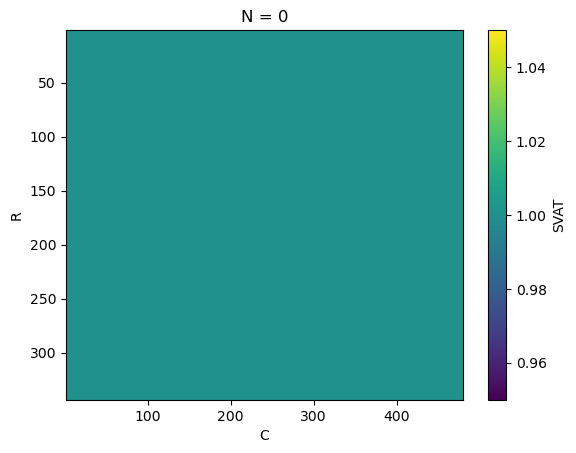

In [17]:
DS['SVAT'].sel(N=0).notnull().plot(yincrease=False)

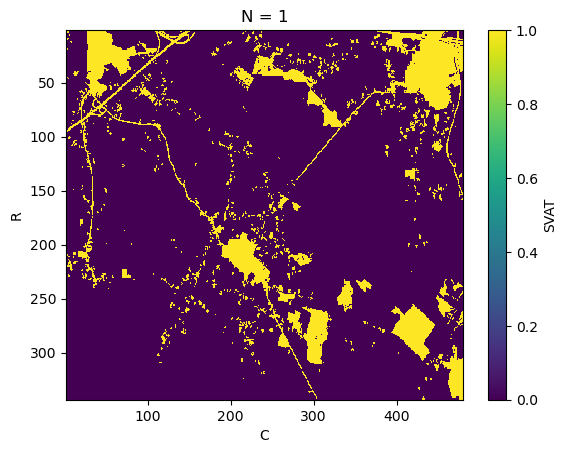

In [18]:
DS['SVAT'].sel(N=1).notnull().plot(yincrease=False)

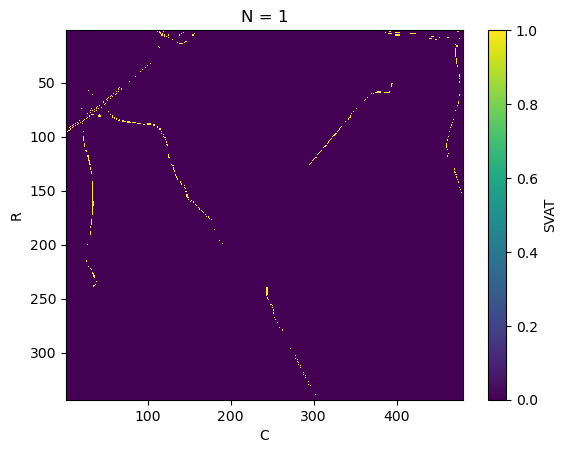

In [19]:
extra = DS['SVAT'].sel(N=1).notnull() & DS_B['SVAT'].sel(N=1).isnull() # Extra SVATs in NBr60 that are not in NBr52
extra.plot(yincrease=False)

#### Explore smaller area, to understand what's happening

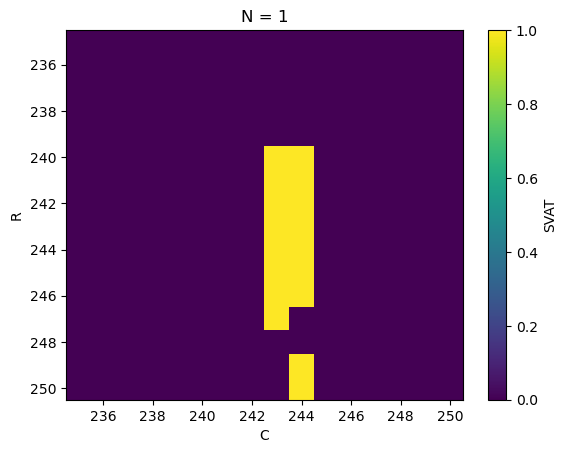

In [20]:
extra = DS['SVAT'].sel(N=1).notnull() & DS_B['SVAT'].sel(N=1).isnull() # Extra SVATs in NBr60 that are not in NBr52
(extra.sel(R=slice(235, 250), C=slice(235, 250))).plot(yincrease=False)

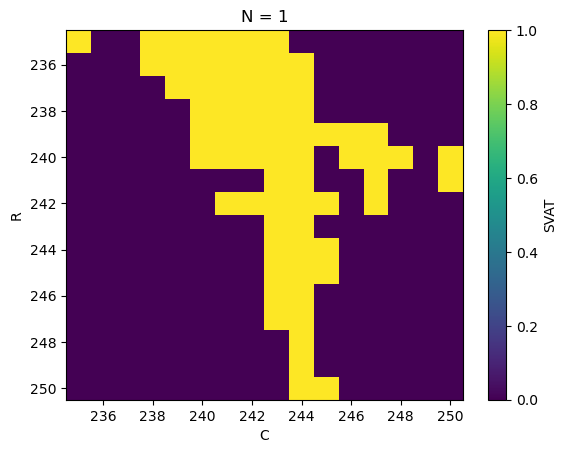

In [21]:
DS['SVAT'].sel(N=1).notnull().sel(R=slice(235, 250), C=slice(235, 250)).plot(yincrease=False)

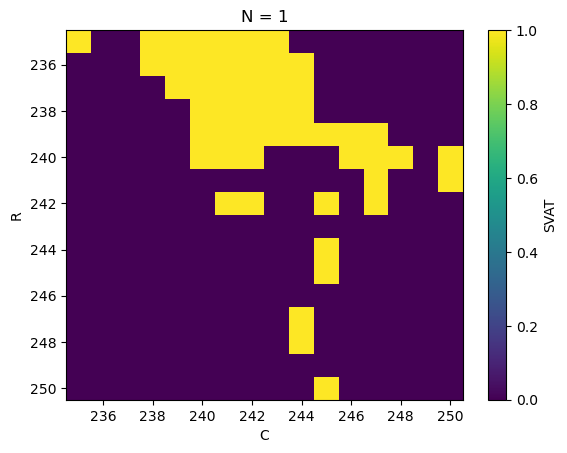

In [22]:
DS_B['SVAT'].sel(N=1).notnull().sel(R=slice(235, 250), C=slice(235, 250)).plot(yincrease=False)

- imod_python (NBr60) creates a 2nd SVAT for the same cell when urban area > 0.
- imod5 (NBr52) creates a 2nd SVAT when urban area > 0 and wetted area <= 20% (not sure about the exact percentage, but I see cells with 75 (or 86.1192) m2 wetted area getting a 2nd SVAT, while cells with 125m2 don't (in both cases urban area > 0)). (total cell area is 625m2)

## 2.1 area_svat

### Compare DFs

In [23]:
Fi = 'area_svat'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

False

In [24]:
DF.describe()

,SVAT,area,temperature at bottom of soil profile,soil physical unit number / or / soil physical unit descriptive string,land use type,root zone thickness / maximum
count,184024.000000,184024.000000,184024.000000,184024.000000,184024.000000,184024.000000
mean,92012.500000,555.089051,12.867458,105.784756,8.750413,0.517066
std,53123.297306,196.266114,5.253305,34.970745,7.183651,0.299450
min,1.000000,0.384169,1.083940,36.000000,1.000000,0.050000
25%,46006.750000,624.237760,8.853417,79.000000,1.000000,0.300000
50%,92012.500000,625.000000,12.353600,84.000000,11.000000,0.350000
75%,138018.250000,625.000000,16.640400,130.000000,17.000000,1.000000
max,184024.000000,625.000000,29.856300,360.000000,22.000000,1.000000


In [25]:
DF_B.describe()

,SVAT,area,temperature at bottom of soil profile,soil physical unit number / or / soil physical unit descriptive string,land use type,root zone thickness / maximum,meteorological region code number,local calibration factor for precipitation,local calibration factor for potential evapotranspiration of reference crop
count,183388.00000,183388.000000,183388.000000,183388.000000,183388.000000,183388.000000,183388.0,183388.0,183388.0
mean,91694.50000,536.798038,12.879104,105.777096,8.718346,0.481972,1.0,1.0,1.0
std,52939.69992,150.606197,5.252083,34.991614,7.175392,0.317850,0.0,0.0,0.0
min,1.00000,1.110000,1.084000,36.000000,1.000000,0.100000,1.0,1.0,1.0
25%,45847.75000,500.000000,8.867000,79.000000,1.000000,0.300000,1.0,1.0,1.0
50%,91694.50000,625.000000,12.360500,84.000000,11.000000,0.350000,1.0,1.0,1.0
75%,137541.25000,625.000000,16.655000,130.000000,17.000000,0.750000,1.0,1.0,1.0
max,183388.00000,625.000000,29.856000,360.000000,22.000000,1.000000,1.0,1.0,1.0


In [26]:
f"{(DF['area'].sum() - DF_B['area'].sum() ) / DF_B['area'].sum() *100:.2f}%"

'3.77%'

We have 3.8% difference in precipitation between runs - it's rounded to the same decimal, so it's probably exactly the same as the area difference.

Let's attach this Fieter to the DS and explore spatially.

### Compare DS Fis

#### area

Let's compare the area per R and C.

In [27]:
param = 'area'

In [28]:
area_RC = DS[param].sum(dim='N', skipna=True)
area_RC_B = DS_B[param].sum(dim='N', skipna=True)
area_RC_Diff = area_RC - area_RC_B

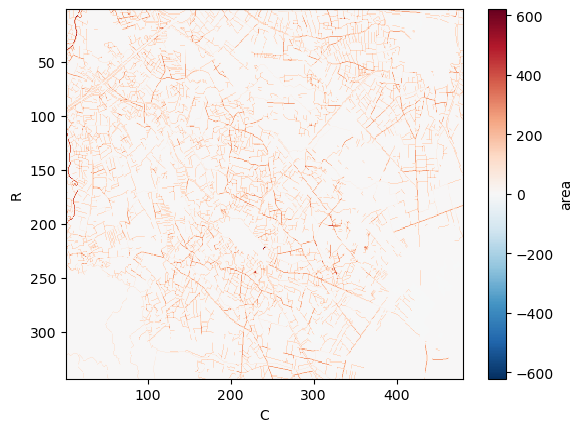

In [29]:
area_RC_Diff.plot(yincrease=False)

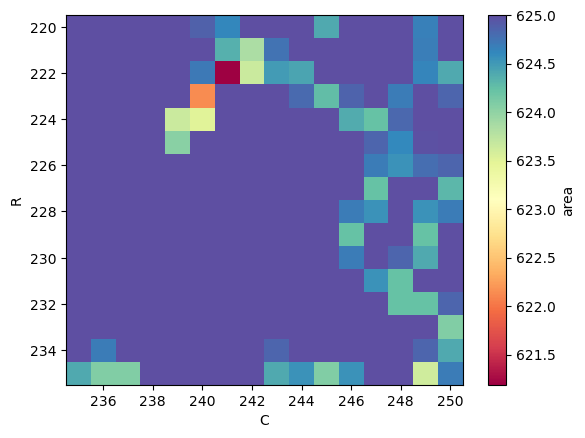

In [30]:
area_RC.sel(R=slice(220, 235), C=slice(235, 250)).plot(yincrease=False, cmap='Spectral')

In [31]:
area_RC.sel(R=slice(220, 235), C=slice(235, 250)).min()

<xarray.DataArray 'area' ()> Size: 8B
array(621.18879)

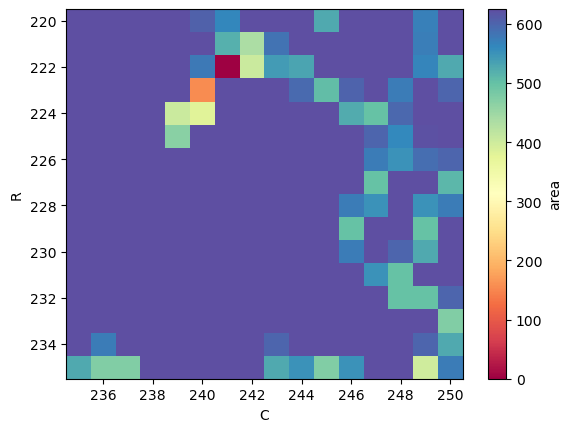

In [32]:
area_RC_B.sel(R=slice(220, 235), C=slice(235, 250)).plot(yincrease=False, cmap='Spectral')

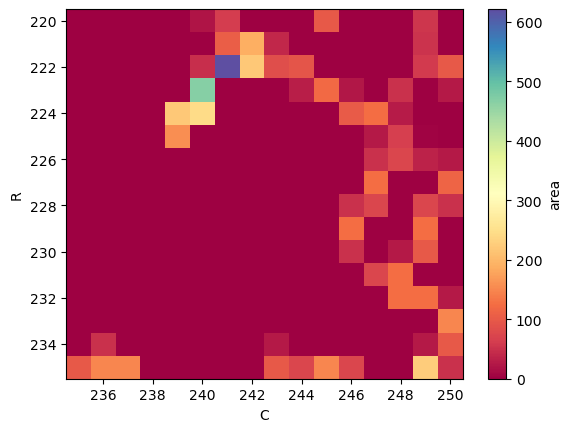

In [33]:
area_RC_Diff.sel(R=slice(220, 235), C=slice(235, 250)).plot(yincrease=False, cmap='Spectral')

It's clear that imod5 removes wetted area from the total cell area. It's not as clear what imod_python does, but there is a big difference in wetted cell areas.

In [34]:
DF.keys()

Index(['SVAT', 'area', 'temperature at bottom of soil profile',
       'soil physical unit number / or / soil physical unit descriptive string',
       'land use type', 'root zone thickness / maximum'],
      dtype='object')

#### temperature at bottom of soil profile

In [35]:
param = DF_B.columns[2]
param

'temperature at bottom of soil profile'

In [36]:
area_RC = DS[param].sum(dim='N', skipna=True)
area_RC_B = DS_B[param].sum(dim='N', skipna=True)
area_RC_Diff = area_RC - area_RC_B

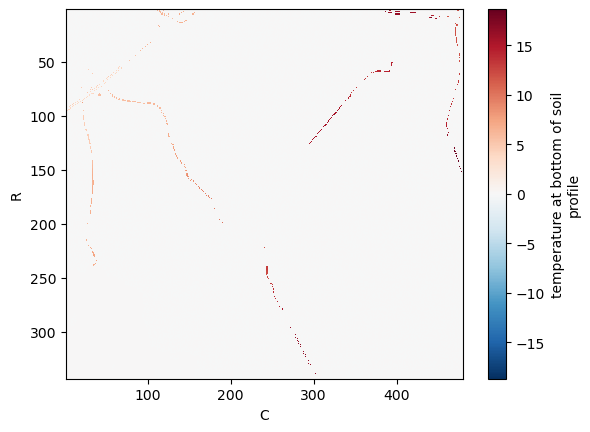

In [37]:
area_RC_Diff.plot(yincrease=False)

This is the same pattern as extra SVATs.

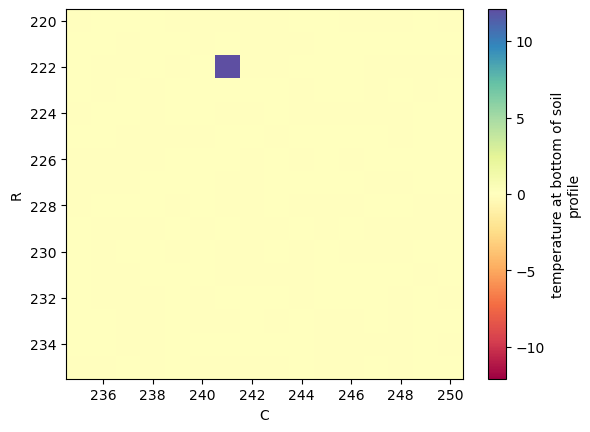

In [38]:
area_RC_Diff.sel(R=slice(220, 235), C=slice(235, 250)).plot(yincrease=False, cmap='Spectral')

#### Other parameters

soil physical unit number / or / soil physical unit descriptive string


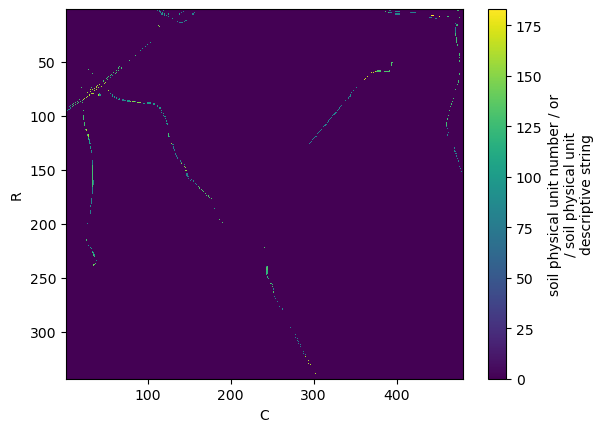

land use type


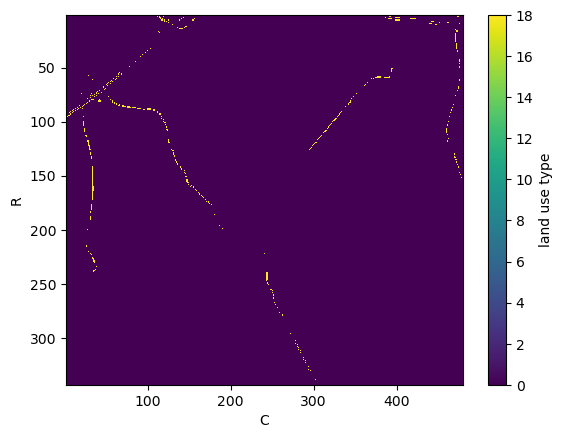

root zone thickness / maximum


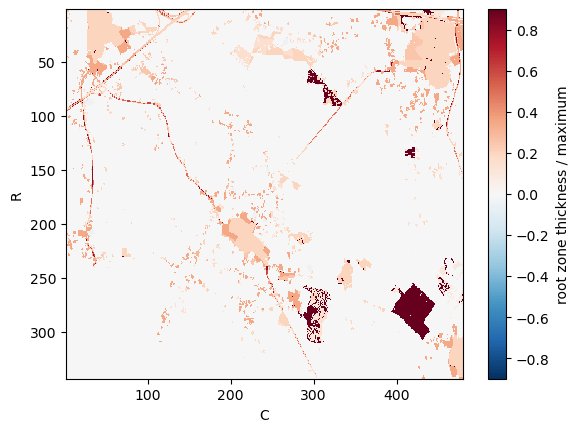

meteorological region code number
local calibration factor for precipitation
local calibration factor for potential evapotranspiration of reference crop


In [46]:
d_missing = {M.MdlN: [], MB.MdlN: []}
for i in range(len(DF_B.columns)-3):
    param = DF_B.columns[3+i]
    print(param)
    if param in DS.data_vars and param in DS_B.data_vars:
        area_RC = DS[param].sum(dim='N', skipna=True)
        area_RC_B = DS_B[param].sum(dim='N', skipna=True)
        area_RC_Diff = area_RC - area_RC_B
        area_RC_Diff.plot(yincrease=False)
        plt.show()
    elif param in DS.data_vars and param not in DS_B.data_vars:
        d_missing[M.MdlN].append(param)
    elif param not in DS.data_vars and param in DS_B.data_vars:
        d_missing[MB.MdlN].append(param)

Other parameters 

## 2.2 fact_svat

In [47]:
Fi = 'fact_svat'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

True

Since DFs are identical, no further investigation is needed.

## 2.4 infi_svat

In [48]:
Fi = 'infi_svat'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

False

In [54]:
DF.describe()

,SVAT,infiltration capacity of soil surface,downward flow resistance of soil surface,upward flow resistance of soil surface,flow resistance of bottom flux link (c-link),extra storage coefficient of phreatic layer
count,184024.000000,184024.000000,184024.0,184024.0,184024.0,184024.0
mean,92012.500000,0.932758,9999.0,9999.0,9999.0,1.0
std,53123.297306,0.330695,0.0,0.0,0.0,0.0
min,1.000000,0.000000,9999.0,9999.0,9999.0,1.0
25%,46006.750000,1.050000,9999.0,9999.0,9999.0,1.0
50%,92012.500000,1.050000,9999.0,9999.0,9999.0,1.0
75%,138018.250000,1.050000,9999.0,9999.0,9999.0,1.0
max,184024.000000,1.050000,9999.0,9999.0,9999.0,1.0


In [55]:
DF_B.describe()

,SVAT,infiltration capacity of soil surface,downward flow resistance of soil surface,upward flow resistance of soil surface,flow resistance of bottom flux link (c-link),extra storage coefficient of phreatic layer
count,183388.00000,183388.000000,183388.0,183388.0,183388.0,183388.0
mean,91694.50000,0.932351,-9999.0,-9999.0,-9999.0,-9999.0
std,52939.69992,0.331196,0.0,0.0,0.0,0.0
min,1.00000,0.000000,-9999.0,-9999.0,-9999.0,-9999.0
25%,45847.75000,1.050000,-9999.0,-9999.0,-9999.0,-9999.0
50%,91694.50000,1.050000,-9999.0,-9999.0,-9999.0,-9999.0
75%,137541.25000,1.050000,-9999.0,-9999.0,-9999.0,-9999.0
max,183388.00000,1.050000,-9999.0,-9999.0,-9999.0,-9999.0


#### infiltration capacity of soil surface

In [56]:
param = 'infiltration capacity of soil surface'
param

'infiltration capacity of soil surface'

In [57]:
area_RC = DS[param].sum(dim='N', skipna=True)
area_RC_B = DS_B[param].sum(dim='N', skipna=True)
area_RC_Diff = area_RC - area_RC_B

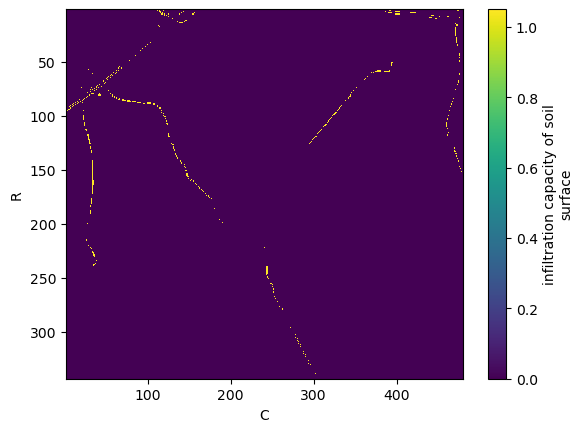

In [58]:
area_RC_Diff.plot(yincrease=False)

This is the same pattern as extra SVATs. The rest of the params are practically NaNs, except "extra storage coefficient of phreatic layer", which also doesn't make a difference (I've tested it).

## 2.5 init_svat

In [60]:
Fi = 'init_svat'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

True

## 2.6 luse_svat

In [61]:
Fi = 'luse_svat'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

True

## 2.7 mete_grid

In [62]:
Fi = 'mete_grid'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

False

In [63]:
DF.describe(include='all')

,time from 00:00:00,year number,path\name precipitation grid,path\name evapotranspiration grid(reference crop values),path\name min. day temperature grid,path\name max. day temperature grid,path\name mean temperature grid,path\name relative sunshine duration grid,path\name radiation grid,path\name humidity grid,path\name wind speed grid
count,4383.000000,4383.000000,4383,4383,4383,4383,4383,4383,4383,4383,4383
unique,NaN,NaN,4383,4383,1,1,1,1,1,1,1
top,NaN,NaN,G:\models\NBr\In\CAP\P\NBr1\P_19930101_NBr1.asc,G:\models\NBr\In\CAP\PET\NBr1\PET_19930101_NBr...,NoValue,NoValue,NoValue,NoValue,NoValue,NoValue,NoValue
freq,NaN,NaN,1,1,4383,4383,4383,4383,4383,4383,4383
mean,182.125257,1998.501027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,105.450673,3.452545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1993.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,91.000000,1996.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,182.000000,1999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,273.000000,2001.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
DF_B.describe(include='all')

,time from 00:00:00,year number,path\name precipitation grid,path\name evapotranspiration grid(reference crop values),path\name min. day temperature grid,path\name max. day temperature grid,path\name mean temperature grid,path\name relative sunshine duration grid,path\name radiation grid,path\name humidity grid,path\name wind speed grid
count,4383.000000,4383.000000,4383,4383,4383,4383,4383,4383,4383,4383,4383
unique,NaN,NaN,4383,4383,1,1,1,1,1,1,1
top,NaN,NaN,G:\models\NBr\In\CAP\P\NBr1\P_19930101_NBr1.asc,G:\models\NBr\In\CAP\PET\NBr1\PET_19930101_NBr...,NoValue,NoValue,NoValue,NoValue,NoValue,NoValue,NoValue
freq,NaN,NaN,1,1,4383,4383,4383,4383,4383,4383,4383
mean,182.125257,1998.501027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,105.450673,3.452545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1993.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,91.000000,1996.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,182.000000,1999.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,273.000000,2001.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
diff_cols = DF.columns[~DF.eq(DF_B).all()]
diff_cols

Index(['path\name precipitation grid', 'path\name evapotranspiration grid(reference crop values)'], dtype='object')

CAPS diffs in path cols. Those definitely don't matter, otherwise I'd be missing all of P/EVT in one Sim.

## 2.8 mod2svat

In [66]:
Fi = 'mod2svat'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

False

In [67]:
diff_cols = DF.columns[~DF.eq(DF_B).all()]
diff_cols

Index(['Modflow-id', 'index of SVAT-unit', 'layer of SVAT-unit'], dtype='object')

In [72]:
DF

,Modflow-id,index of SVAT-unit,layer of SVAT-unit
0,1299310,1,13
1,1299311,2,13
2,1299312,3,13
3,1752082,117,17
4,1752083,118,17
...,...,...,...
211462,164635,184020,1
211463,164636,184021,1
211464,164637,184022,1
211465,164638,184023,1


In [68]:
DF.describe(include='all')

,Modflow-id,index of SVAT-unit,layer of SVAT-unit
count,2.114670e+05,211467.000000,211467.000000
mean,2.840734e+05,91266.550871,2.894149
std,5.344250e+05,53119.757743,4.950680
min,4.820000e+02,1.000000,1.000000
25%,4.323250e+04,45523.500000,1.000000
50%,9.399400e+04,90998.000000,1.000000
75%,1.405655e+05,138014.500000,1.000000
max,2.174030e+06,184024.000000,19.000000


In [69]:
DF_B.describe(include='all')

,Modflow-id,index of SVAT-unit,layer of SVAT-unit
count,2.091740e+05,209174.000000,209174.000000
mean,2.743038e+05,91809.175270,2.799927
std,5.237708e+05,53199.856967,4.845565
min,4.820000e+02,1.000000,1.000000
25%,4.299725e+04,46011.250000,1.000000
50%,9.344250e+04,91876.500000,1.000000
75%,1.395698e+05,137687.000000,1.000000
max,2.172913e+06,183388.000000,19.000000


## 2.9 para_sim

In [77]:
Fi = 'para_sim'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

False

Comments left in .xlsx

Non Array-like, so there is no further exploration.

## 2.10 scap_svat

In [79]:
Fi = 'scap_svat'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

False

In [80]:
diff_cols = DF.columns[~DF.eq(DF_B).all()]
diff_cols

Index(['SVAT', 'maximum abstraction from groundwater mm/d',
       'maximum abstraction from surface water mm/d',
       'maximum abstraction from groundwater m3/d',
       'fraction of abstraction from surface water m3/d'],
      dtype='object')

In [81]:
DF.describe(include='all')

,SVAT,maximum abstraction from groundwater mm/d,maximum abstraction from surface water mm/d,maximum abstraction from groundwater m3/d,fraction of abstraction from surface water m3/d
count,25812.000000,0.0,0.0,25812.000000,25812.0
mean,80837.406439,NaN,NaN,15.621422,0.0
std,49697.040372,NaN,NaN,0.008541,0.0
min,1.000000,NaN,NaN,15.518300,0.0
25%,38281.750000,NaN,NaN,15.625000,0.0
50%,81736.500000,NaN,NaN,15.625000,0.0
75%,125832.250000,NaN,NaN,15.625000,0.0
max,163471.000000,NaN,NaN,15.625000,0.0


In [82]:
DF_B.describe(include='all')

,SVAT,maximum abstraction from groundwater mm/d,maximum abstraction from surface water mm/d,maximum abstraction from groundwater m3/d,fraction of abstraction from surface water m3/d
count,25786.000000,25786.0,0.0,0.0,0.0
mean,92624.736756,25.0,NaN,NaN,NaN
std,55008.758796,0.0,NaN,NaN,NaN
min,1.000000,25.0,NaN,NaN,NaN
25%,47826.250000,25.0,NaN,NaN,NaN
50%,93258.500000,25.0,NaN,NaN,NaN
75%,141819.750000,25.0,NaN,NaN,NaN
max,183378.000000,25.0,NaN,NaN,NaN


## 2.11 sel_key_svat_per

In [84]:
Fi = 'sel_key_svat_per'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

True

## 2.13 svat2etrefgrid

In [85]:
Fi = 'svat2etrefgrid'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

False

In [88]:
DF.describe()

,SVAT,row number of ETREF grid,column number of ETREF grid
count,184024.000000,184024.000000,184024.000000
mean,92012.500000,233.503760,119.721254
std,53123.297306,2.530364,3.498742
min,1.000000,229.000000,114.000000
25%,46006.750000,231.000000,117.000000
50%,92012.500000,234.000000,120.000000
75%,138018.250000,236.000000,123.000000
max,184024.000000,238.000000,126.000000


In [89]:
DF_B.describe(include='all')

,SVAT,row number of ETREF grid,column number of ETREF grid
count,183388.00000,183388.000000,183388.000000
mean,91694.50000,233.508937,119.725816
std,52939.69992,2.530613,3.495910
min,1.00000,229.000000,114.000000
25%,45847.75000,231.000000,117.000000
50%,91694.50000,234.000000,120.000000
75%,137541.25000,236.000000,123.000000
max,183388.00000,238.000000,126.000000


## 2.14 svat2precgrid

In [90]:
Fi = 'svat2precgrid'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

False

In [91]:
DF.describe()

,SVAT,row number of PREC grid,column number of PREC grid
count,184024.000000,184024.000000,184024.000000
mean,92012.500000,233.503760,119.721254
std,53123.297306,2.530364,3.498742
min,1.000000,229.000000,114.000000
25%,46006.750000,231.000000,117.000000
50%,92012.500000,234.000000,120.000000
75%,138018.250000,236.000000,123.000000
max,184024.000000,238.000000,126.000000


In [92]:
DF_B.describe(include='all')

,SVAT,row number of PREC grid,column number of PREC grid
count,183388.00000,183388.000000,183388.000000
mean,91694.50000,233.508937,119.725816
std,52939.69992,2.530613,3.495910
min,1.00000,229.000000,114.000000
25%,45847.75000,231.000000,117.000000
50%,91694.50000,234.000000,120.000000
75%,137541.25000,236.000000,123.000000
max,183388.00000,238.000000,126.000000


## 2.15 svat2swnr_roff

In [93]:
Fi = 'svat2swnr_roff'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

False

In [95]:
DF.describe()

,SVAT,surface water location identifier,"micro-storage capacity, =sill of the runoff relationship",runoff resistance,runon resistance
count,184024.000000,184024.0,1.840240e+05,184024.0,184024.0
mean,92012.500000,0.0,2.000000e-03,1.0,1.0
std,53123.297306,0.0,5.593197e-15,0.0,0.0
min,1.000000,0.0,2.000000e-03,1.0,1.0
25%,46006.750000,0.0,2.000000e-03,1.0,1.0
50%,92012.500000,0.0,2.000000e-03,1.0,1.0
75%,138018.250000,0.0,2.000000e-03,1.0,1.0
max,184024.000000,0.0,2.000000e-03,1.0,1.0


In [96]:
DF_B.describe(include='all')

,SVAT,surface water location identifier,"micro-storage capacity, =sill of the runoff relationship",runoff resistance,runon resistance
count,183388.00000,183388.0,1.833880e+05,183388.0,183388.0
mean,91694.50000,0.0,2.000000e-03,1.0,1.0
std,52939.69992,0.0,5.579320e-15,0.0,0.0
min,1.00000,0.0,2.000000e-03,1.0,1.0
25%,45847.75000,0.0,2.000000e-03,1.0,1.0
50%,91694.50000,0.0,2.000000e-03,1.0,1.0
75%,137541.25000,0.0,2.000000e-03,1.0,1.0
max,183388.00000,0.0,2.000000e-03,1.0,1.0


## 2.17 tiop_sim 

In [97]:
Fi = 'tiop_sim'
DF, DF_B = M.MSW_In.d[Fi].copy(), MB.MSW_In.d[Fi].copy()
DF.equals(DF_B)

False

In [98]:
DF.describe()

,time from beginning of year at 00:00:00,year number,option number
count,93.000000,93.0,93.0
mean,46.000000,1996.0,7.0
std,26.990739,0.0,0.0
min,0.000000,1996.0,7.0
25%,23.000000,1996.0,7.0
50%,46.000000,1996.0,7.0
75%,69.000000,1996.0,7.0
max,92.000000,1996.0,7.0


In [99]:
DF_B.describe(include='all')

,time from beginning of year at 00:00:00,year number,option number
count,10227.000000,10227.000000,10227.0
mean,182.125257,2006.501027,7.0
std,105.443798,8.078184,0.0
min,0.000000,1993.000000,7.0
25%,91.000000,2000.000000,7.0
50%,182.000000,2007.000000,7.0
75%,273.000000,2013.500000,7.0
max,365.000000,2020.000000,7.0


## 2.18 uscl_svat

Missing in NBr54

# -1 Junkyard

In [ ]:
for k in MB.MSW_In.d.keys():
    try:
        print('\n'.join(MB.MSW_In.d[k].columns))
        print('---------------------')
    except:
        continue